In [2]:
pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns # making statistical graphics
from scipy import stats


from sklearn.svm import SVC 
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
#import xgboost as xgb
#from catboost import CatBoostClassifier
#from lightgbm import LGBMClassifier

from sklearn.model_selection import cross_val_score

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

#from imblearn.over_sampling import SMOTE




# Description Data

In [4]:
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

print("training dataset shape is: ",train_df.shape)
print("testing dataset shape is " ,test_df.shape)

train_df.head()

training dataset shape is:  (8693, 14)
testing dataset shape is  (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
print(f"Duplicates in train dataset is  {train_df.duplicated().sum()}, donc comme pourcentage ({100*train_df.duplicated().sum()/len(train_df)})%")

print("data types of features of training data")
print(train_df.dtypes)
print("\n"+"-"*100)
print("\nData type of testing data is")
print(test_df.dtypes)

Duplicates in train dataset is  0, donc comme pourcentage (0.0)%
data types of features of training data
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

----------------------------------------------------------------------------------------------------

Data type of testing data is
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
dtype: object


Check percentage missing values train data

In [6]:
df1 = (train_df.isnull().sum()[train_df.isnull().sum()>0]).to_frame().rename(columns={0:"Number of Missing values"})
df1["% of Missing values"] = round((100*train_df.isnull().sum()[train_df.isnull().sum()>0]/len(train_df)),2)
df1

,Number of Missing values,% of Missing values
HomePlanet,201,2.31
CryoSleep,217,2.50
Cabin,199,2.29
Destination,182,2.09
Age,179,2.06
VIP,203,2.34
RoomService,181,2.08
FoodCourt,183,2.11
ShoppingMall,208,2.39
Spa,183,2.11


check percentage missing values test data

In [7]:
df2 = (test_df.isnull().sum()[test_df.isnull().sum()>0]).to_frame().rename(columns={0:"Number of Missing values"})
df2["% of Missing Values"] = round((100*test_df.isnull().sum()[test_df.isnull().sum()>0]/len(test_df)),2).values
df2

,Number of Missing values,% of Missing Values
HomePlanet,87,2.03
CryoSleep,93,2.17
Cabin,100,2.34
Destination,92,2.15
Age,91,2.13
VIP,93,2.17
RoomService,82,1.92
FoodCourt,106,2.48
ShoppingMall,98,2.29
Spa,101,2.36


Cardinal of features of type object

In [8]:
print("cardinality of categorical features in training datasets is:")
print(train_df.select_dtypes(include="object").nunique())
print("\n","-"*70)
print("\nCardinality of categorical features in testing datsets is:")
print(test_df.select_dtypes(include="object").nunique())

cardinality of categorical features in training datasets is:
PassengerId    8693
HomePlanet        3
CryoSleep         2
Cabin          6560
Destination       3
VIP               2
Name           8473
dtype: int64

 ----------------------------------------------------------------------

Cardinality of categorical features in testing datsets is:
PassengerId    4277
HomePlanet        3
CryoSleep         2
Cabin          3265
Destination       3
VIP               2
Name           4176
dtype: int64


PassagerId Cabin and Name high cardinality 

we create new feature from this features

# Exploratory data analysis

Age feature visualizing 

Text(0.5, 1.0, 'Age feature distribution')

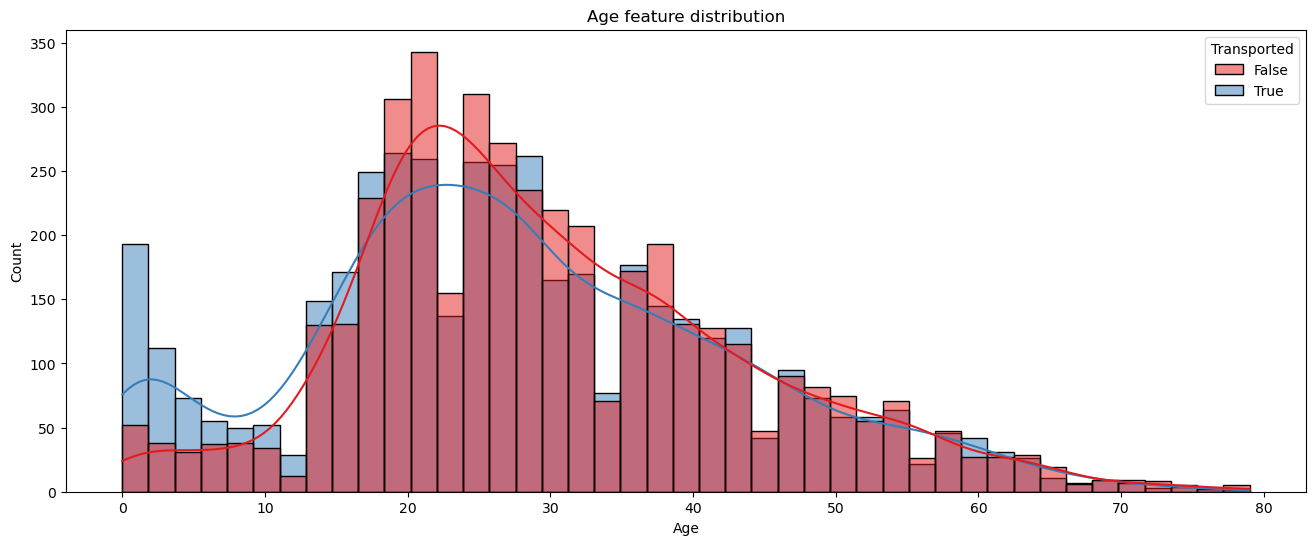

In [9]:
plt.figure(figsize=(16,6))
sns.histplot(x=train_df["Age"], hue="Transported",data=train_df, kde=True,  palette="Set1")
plt.title("Age feature distribution")

* Most of the passenger were between age 18-32
* Age from 0-18 highly transported especially for new born
* Age from 18-32 passengers are comparatively less transported when compared to not transported passengers.
* Age above 32 seems to be equally transported when compared to not transported passengers

Insights
* We can create a new feature Age-Catgeory from age in which we can split ages into different categories.

C:\Users\mkoud\AppData\Local\Temp\ipykernel_23516\1969993731.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\mkoud\AppData\Local\Temp\ipykernel_23516\1969993731.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\mkoud\AppData\Local\Temp\ipykernel_23516\1969993731.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\mkoud\AppData\Local\Temp\ipykernel_23516\1969993731.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


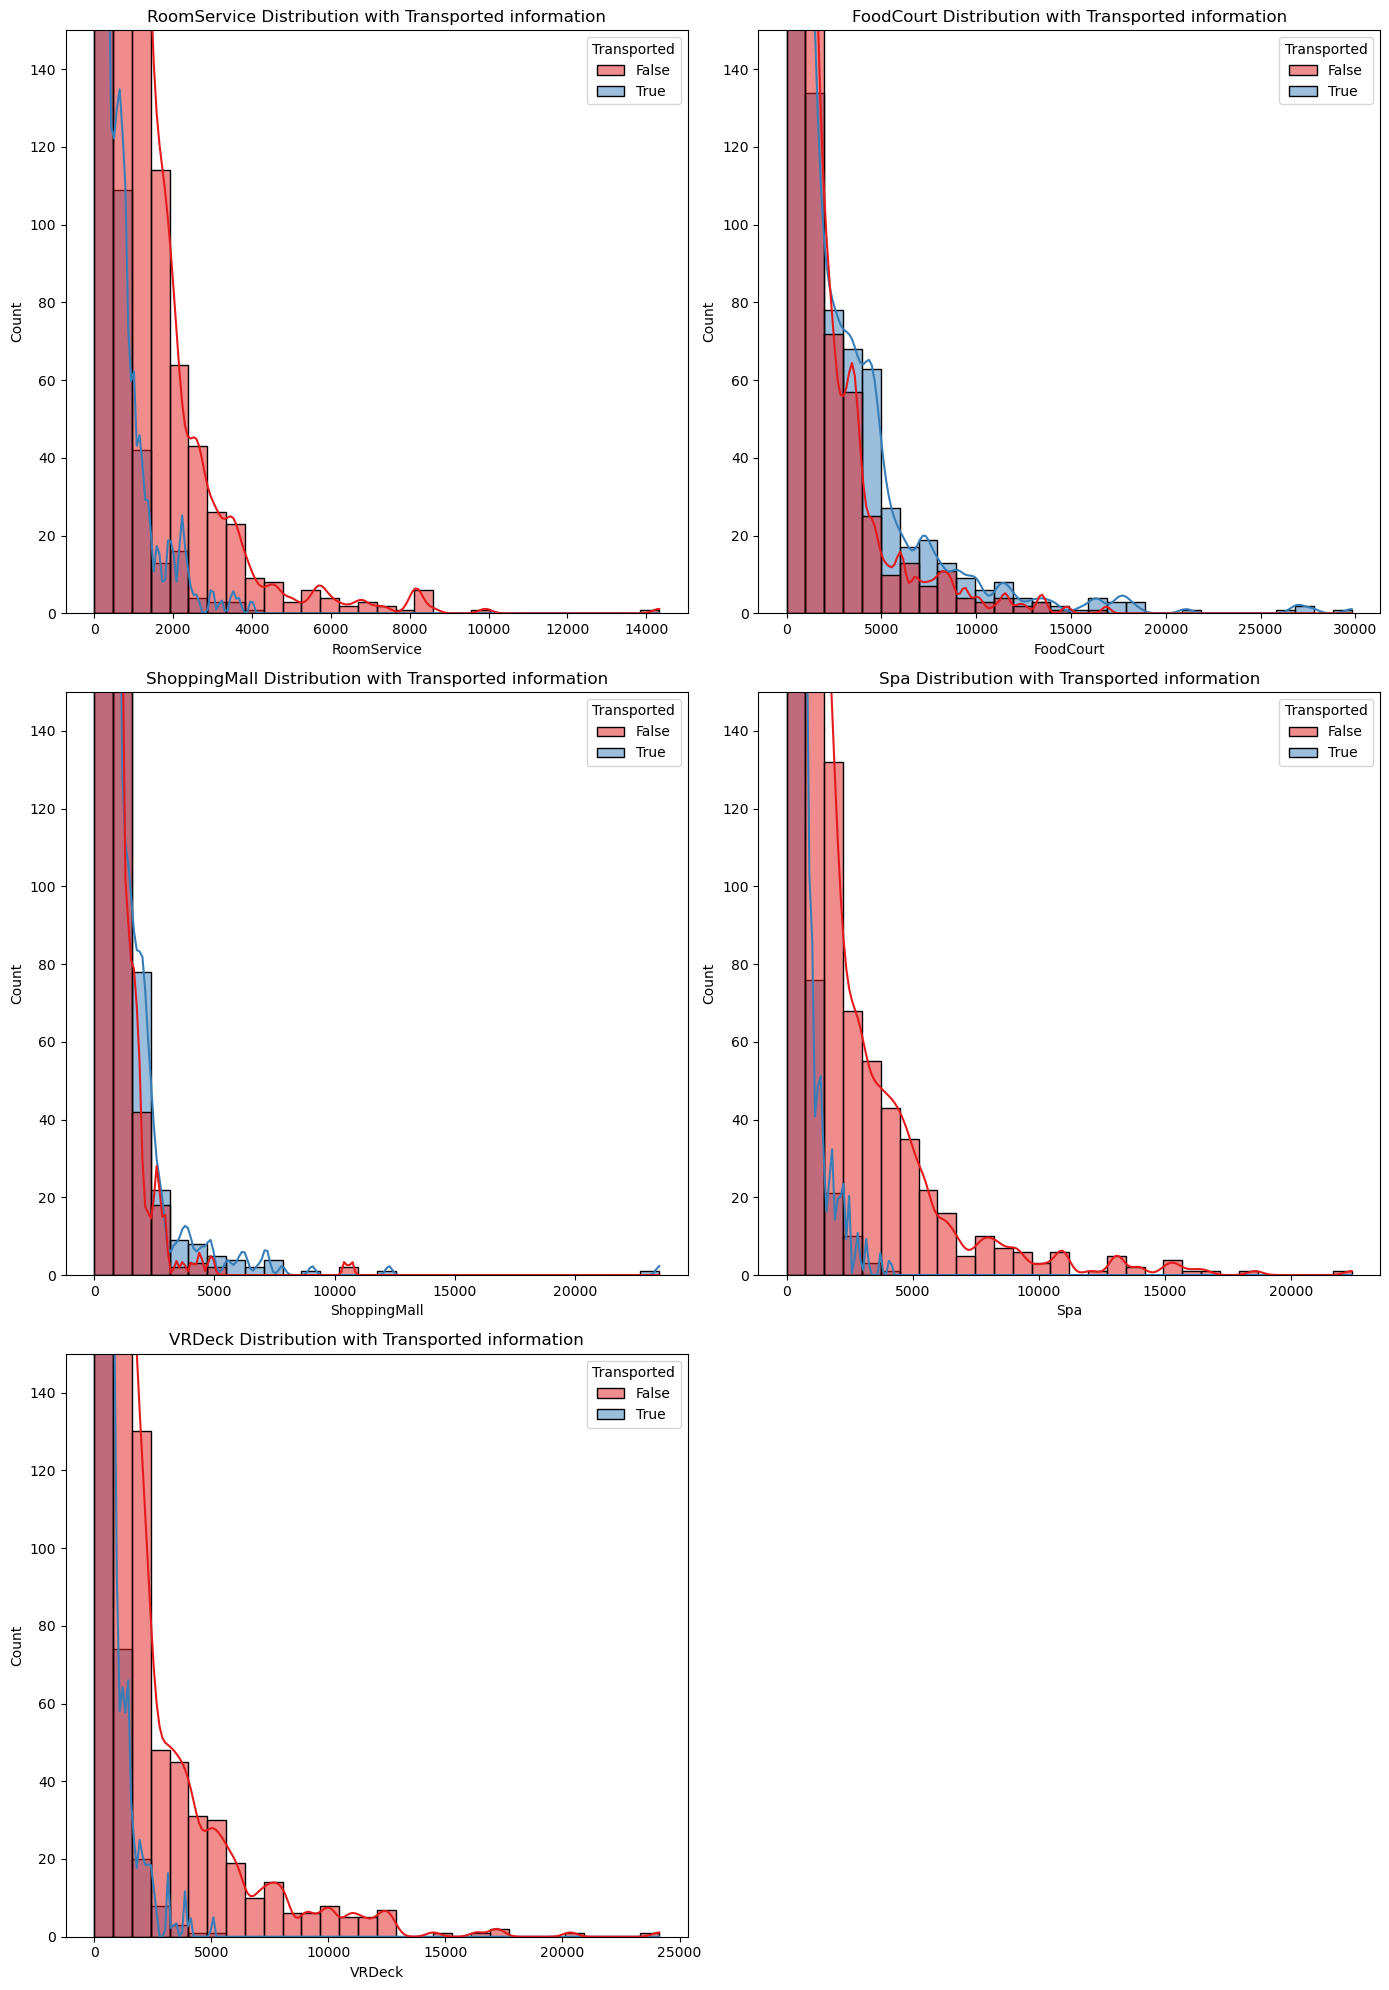

In [10]:
expenditures = ["RoomService","FoodCourt","ShoppingMall","Spa","VRDeck"]

plt.figure(figsize=(14,20))
for idx, column in enumerate (expenditures):
    plt.subplot(3,2,idx+1)
    sns.histplot(x=column, hue="Transported", data=train_df,
                 bins=30, kde=True, palette="Set1")
    plt.title(f"{column} Distribution with Transported information")
    plt.ylim(0,150)
    plt.tight_layout()


We can observe that most of the passengers doesn't seems to expend any money.
Since most of the expenses are 0 so the values with higher expenses are kind of outliers in our data.

roomservice , spa vrdeck similar distrib

foodcourt, shoppingmall same

all Right Skewed ==> 

Passengers having less expenses are more likely to be transported than passengers having high expenses.

---------------------------

log transformation before model building

Total expenditure indicate total expenses 

Since, most people expense is 0 so we can create a new boolean feature No Spending indicating whether the passenger total expense is 0 or not.

We can split Total Expenditure into different categories of expenditure like Low , Medium & High Expenses and create one more new feature Expenditure Category

## Visualizing Homeplanet, Cryosleep, destination, VIP

C:\Users\mkoud\AppData\Local\Temp\ipykernel_23516\1148533474.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\mkoud\AppData\Local\Temp\ipykernel_23516\1148533474.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\mkoud\AppData\Local\Temp\ipykernel_23516\1148533474.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


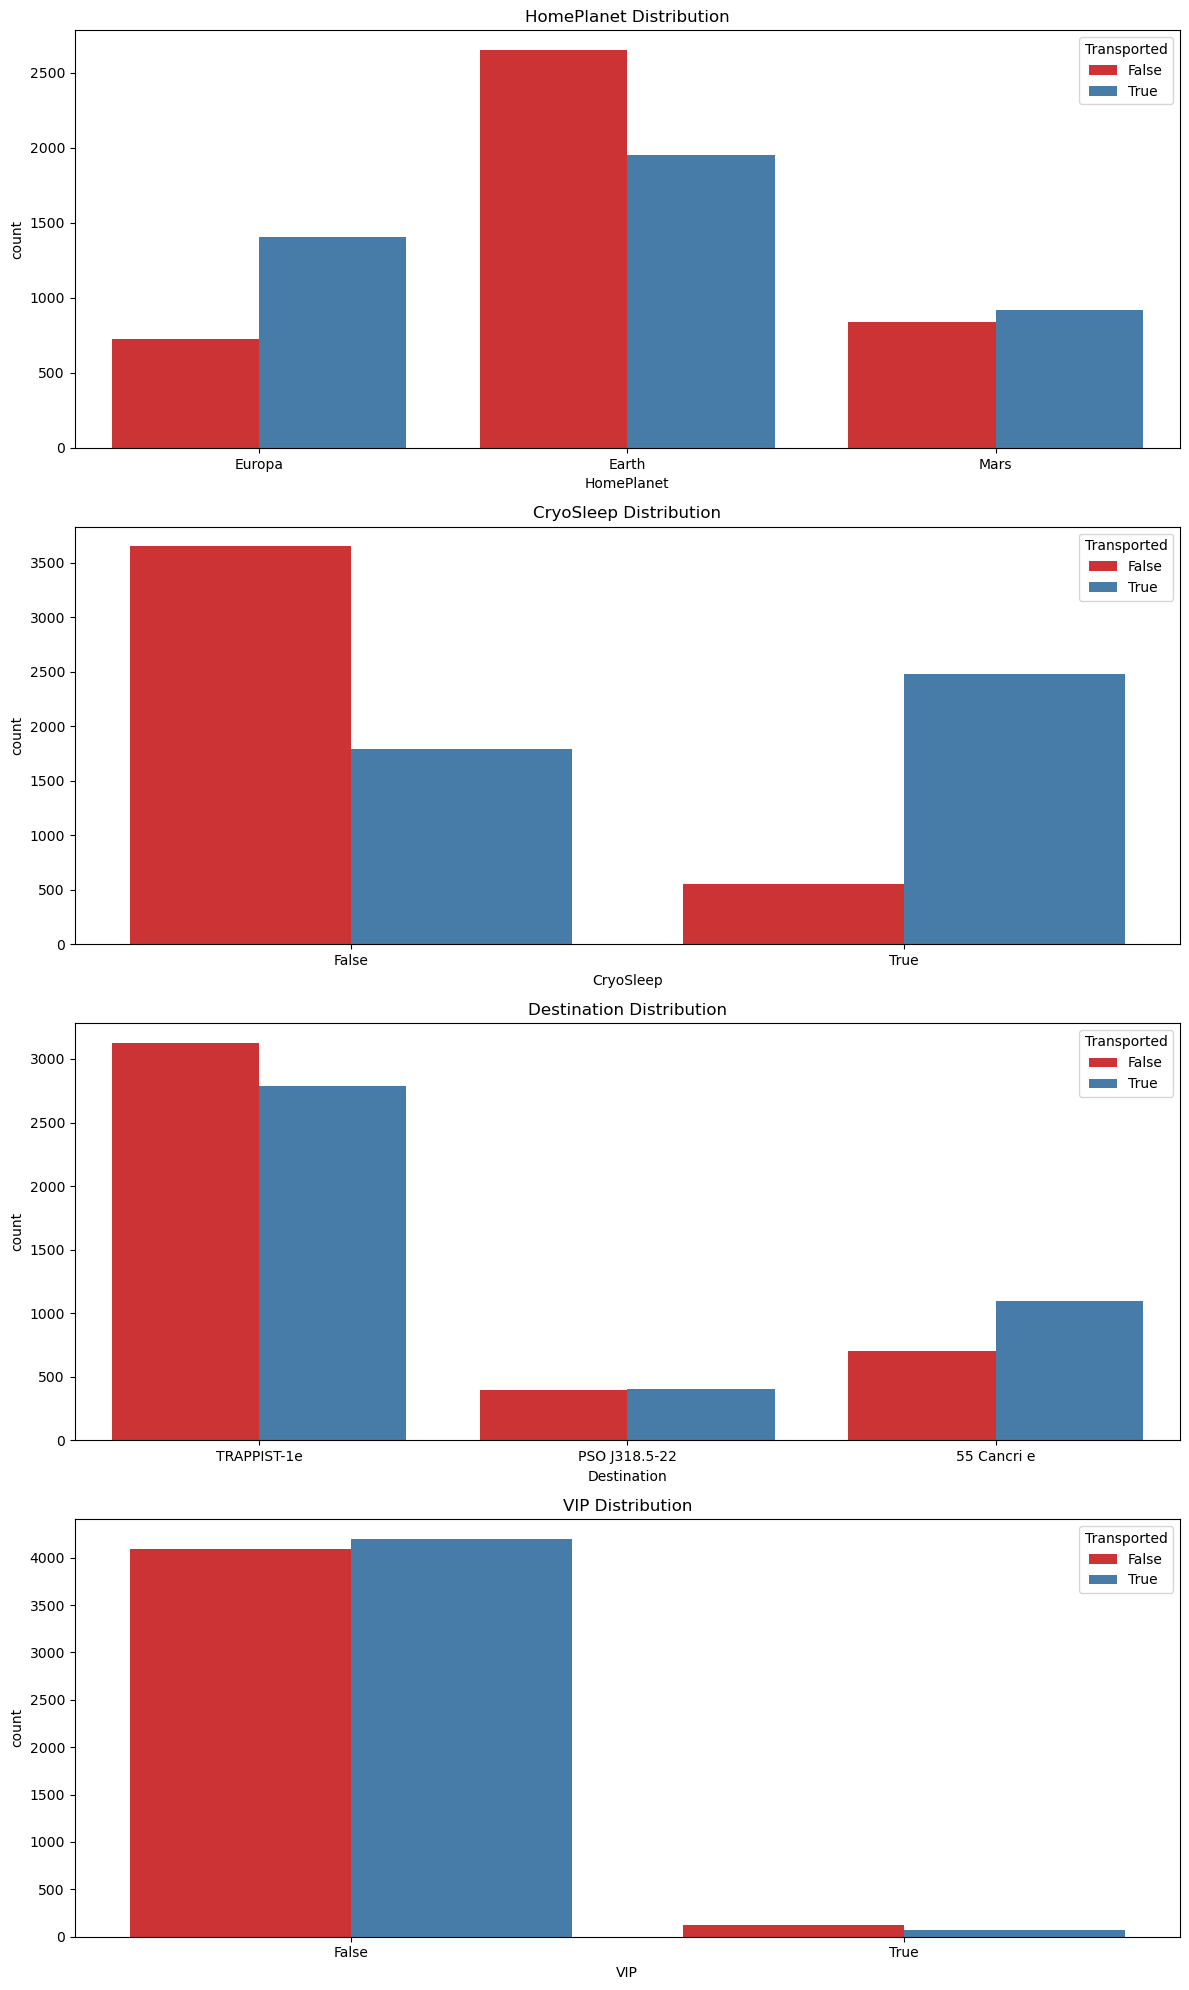

In [11]:
cat_cols = ["HomePlanet","CryoSleep","Destination","VIP"]

plt.figure(figsize=(12,20))
for idx,column in enumerate(cat_cols):
    plt.subplot(4,1,idx+1)
    sns.countplot(x=column, hue="Transported", data=train_df, palette="Set1")
    plt.title(f"{column} Distribution")
    plt.tight_layout()

In HomePlanet feature we can observe that most of passenger are from Earth but passenger from Earth are Comparatively Less Transported, passenger from Mars are Equally Transported, and passengers from Europa are Highly Transported.

In Destination feature we can observe that most of the passengers are transported to Trappist-1e.

In VIP feature we can observe that one cateogry is dominating other category too much. So it doesn't seem to be usefull feature because it can lead to overfitting in our model.

So it's better to drop VIP feature before Model building

--------------
We have visualized all the features expect PassengerId, Name, Cabin features. We can't visualize this features because they are having high cardinality.


# Feature Engineering

## PassengerId

In [12]:
train_df["PassengerId"].to_frame().head()

,PassengerId
0,0001_01
1,0002_01
2,0003_01
3,0003_02
4,0004_01


We can create a new feature Group_Size which will indicate total number of members present in each group.

feature Travelling Solo indicating whether the passenger is travelling solo or in a group.

In [13]:
def passagerid_new_features(df):
    df["Group"] = df["PassengerId"].apply(lambda x: x.split("_")[0])
    df["Member"] = df["PassengerId"].apply(lambda x: x.split("_")[1])

    # grouping the group feature with respect to "member" feature to check
    # which group is travelling with how many member 

    x = df.groupby("Group")["Member"].count()

    # creating a set of group values which are travelling with more than 1 member
    y = set(x[x>1].index)

    df["Travelling_Solo"] = df["Group"].apply(lambda x : x not in y)

    #creating a new feature "group_size" which will indicate each group nb of members

    df["Group_size"] = 0
    for i in x.items():
        df.loc[df["Group"]==i[0],"Group_size"] = i[1]


passagerid_new_features(train_df)
passagerid_new_features(test_df)
train_df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Group,Member,Travelling_Solo,Group_size
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0001,01,True,1
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,0002,01,True,1
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,0003,01,False,2
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,0003,02,False,2
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,0004,01,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False,9276,01,True,1
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False,9278,01,True,1
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True,9279,01,True,1
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False,9280,01,False,2


In [14]:
train_df.drop(columns=["Group","Member"],inplace=True)
test_df.drop(columns=["Group","Member"],inplace=True)

visualizing "group_size" & "travelling_solo"

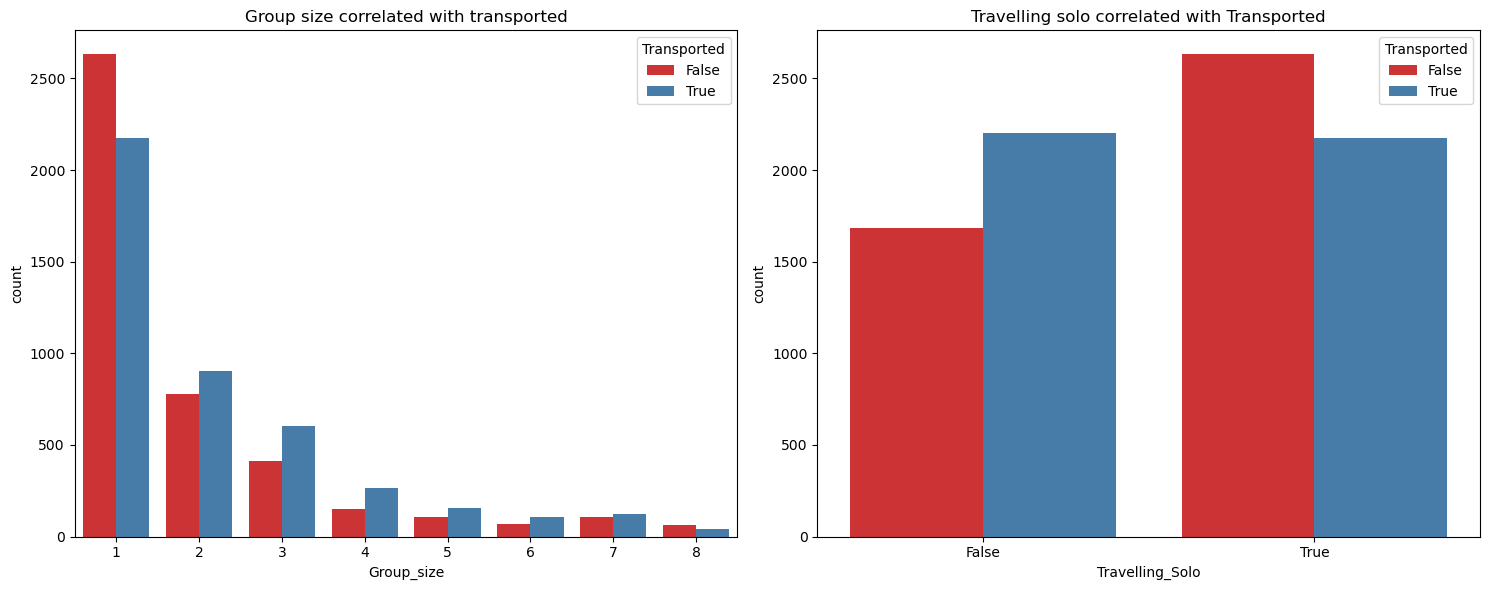

In [15]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
sns.countplot(x="Group_size", hue="Transported" ,data=train_df, palette="Set1")
plt.title("Group size correlated with transported")

plt.subplot(1,2,2)
sns.countplot(x="Travelling_Solo", hue="Transported", data=train_df, palette="Set1")
plt.title("Travelling solo correlated with Transported")
plt.tight_layout()
plt.show()

From Group_Size feature we can observe that most the passengers are travelling alone.

From Travelling_Solo feature we can observe that passengers travelling solo are comparatively less transported when compared with passenger travelling in group.

## New Feature from "Cabin"

In [16]:
train_df["Cabin"].head().to_frame()

,Cabin
0,B/0/P
1,F/0/S
2,A/0/S
3,A/0/S
4,F/1/S


deck/number/side

In [17]:
import numpy as np

def cabin_new_feature(df):
    df["Cabin"].fillna("np.nan/np.nan/np.nan", inplace=True)
    
    df["Cabin_Deck"] = df["Cabin"].apply(lambda x: x.split("/")[0])
    df["Cabin_Number"] = df["Cabin"].apply(lambda x: x.split("/")[1])
    df["Cabin_Side"] = df["Cabin"].apply(lambda x: x.split("/")[2])
    
    # Remplacer les valeurs de chaîne 'np.nan' par des valeurs NaN de numpy
    cols = ["Cabin_Deck", "Cabin_Number", "Cabin_Side"]
    df[cols] = df[cols].replace("np.nan", np.nan)
    
    # Remplir les valeurs manquantes dans les nouvelles caractéristiques créées
    df["Cabin_Deck"].fillna(df["Cabin_Deck"].mode()[0], inplace=True)
    df["Cabin_Side"].fillna(df["Cabin_Side"].mode()[0], inplace=True)
    df["Cabin_Number"] = pd.to_numeric(df["Cabin_Number"], errors='coerce')  # Conversion en numérique
    df["Cabin_Number"].fillna(df["Cabin_Number"].median(), inplace=True)

cabin_new_feature(train_df)
cabin_new_feature(test_df)

 ## Cabine Deck distribution

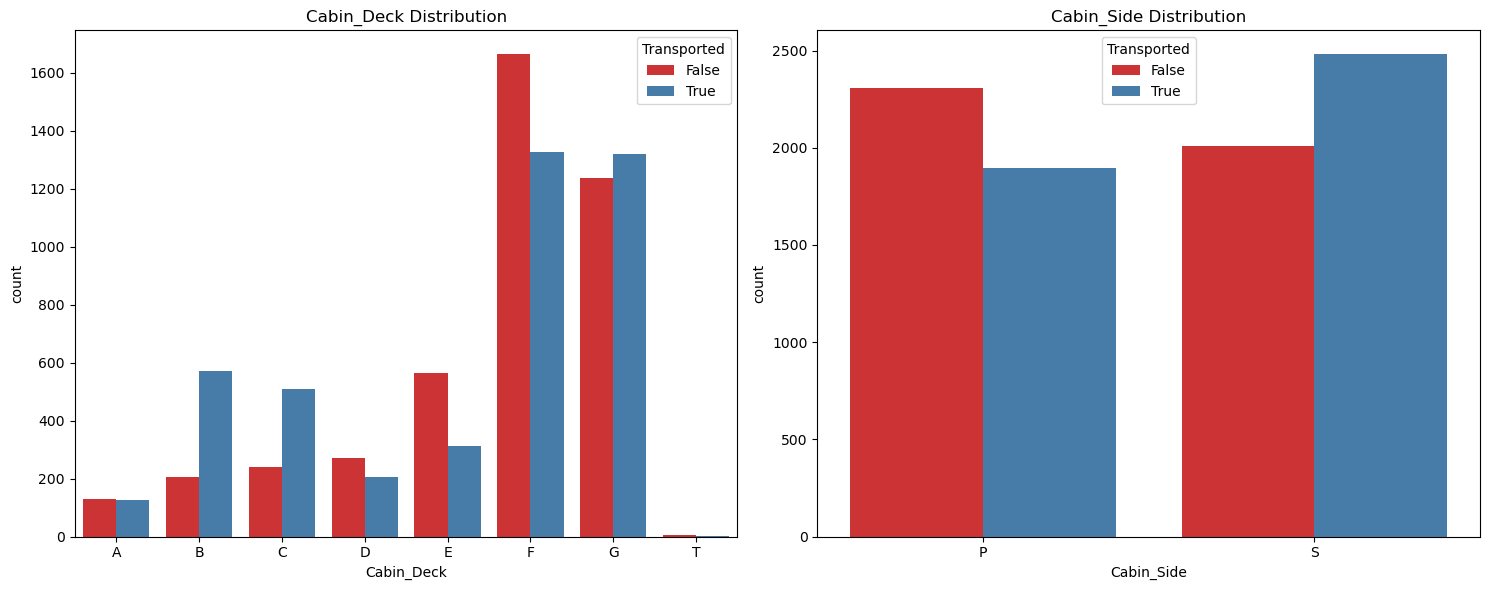

In [18]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
sns.countplot(x="Cabin_Deck",hue="Transported", data=train_df, palette="Set1",order=["A","B","C","D","E","F","G","T"])
plt.title("Cabin_Deck Distribution")

plt.subplot(1,2,2)
sns.countplot(x="Cabin_Side", hue="Transported", data=train_df, palette="Set1")
plt.title("Cabin_Side Distribution")
plt.tight_layout()
plt.show()

A partir du Cabin_Deck il y a un max de personne dans  F & G Deck.
les personnes des cabines B et C sont beaucoup transportées

A partir de Cabin_Side 50/50 entre S et P.
cabin_side S sont + transportés 

## deck number representation

Total Unique values present in Cabin_Number feature is: 1817
 la moyenne des Cabin_Number est :  596.3989416772115
la mediane des Cabin_Number est: 427.0
le min des Cabin_Number feature est: 0
le max des Cabin_number Feature est: 1894


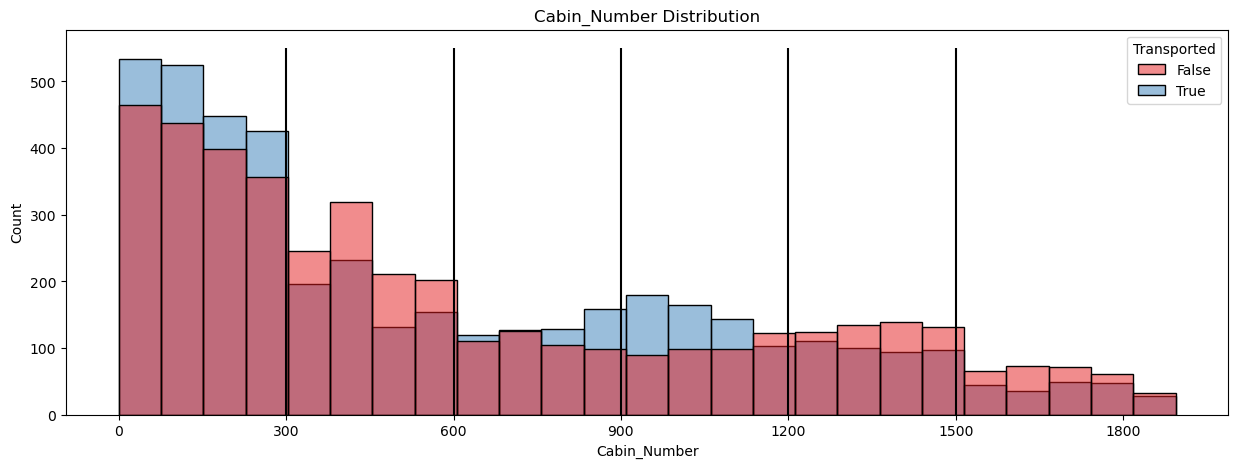

In [19]:
train_df["Cabin_Number"] = train_df["Cabin_Number"].astype(int)
test_df["Cabin_Number"] = test_df["Cabin_Number"].astype(int)

print("Total Unique values present in Cabin_Number feature is:",train_df["Cabin_Number"].nunique())
print(" la moyenne des Cabin_Number est : ",train_df["Cabin_Number"].mean())
print("la mediane des Cabin_Number est:",train_df["Cabin_Number"].median())
print("le min des Cabin_Number feature est:",train_df["Cabin_Number"].min())
print("le max des Cabin_number Feature est:",train_df["Cabin_Number"].max())

plt.figure(figsize=(15,5))
sns.histplot(x="Cabin_Number",data=train_df,hue="Transported",palette="Set1")
plt.title("Cabin_Number Distribution")
plt.xticks(list(range(0,1900,300)))
plt.vlines(300,ymin=0,ymax=550,color="black")
plt.vlines(600,ymin=0,ymax=550,color="black")
plt.vlines(900,ymin=0,ymax=550,color="black")
plt.vlines(1200,ymin=0,ymax=550,color="black")
plt.vlines(1500,ymin=0,ymax=550,color="black")
plt.show()


In [20]:
def cabin_regions(df):
    df["Cabin_Region1"] = (df["Cabin_Number"]<300)
    df["Cabin_Region2"] = (df["Cabin_Number"]>=300) & (df["Cabin_Number"]<600)
    df["Cabin_Region3"] = (df["Cabin_Number"]>=600) & (df["Cabin_Number"]<900)
    df["Cabin_Region4"] = (df["Cabin_Number"]>=900) & (df["Cabin_Number"]<1200)
    df["Cabin_Region5"] = (df["Cabin_Number"]>=1200) & (df["Cabin_Number"]<1500)
    df["Cabin_Region6"] = (df["Cabin_Number"]>=1500)

cabin_regions(train_df)
cabin_regions(test_df)
train_df.drop(columns=["Cabin_Number"],inplace=True)
test_df.drop(columns=["Cabin_Number"],inplace=True)

## visualizing "cabin_region"

C:\Users\mkoud\AppData\Local\Temp\ipykernel_23516\2002583749.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\mkoud\AppData\Local\Temp\ipykernel_23516\2002583749.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\mkoud\AppData\Local\Temp\ipykernel_23516\2002583749.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\mkoud\AppData\Local\Temp\ipykernel_23516\2002583749.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\mkoud\AppData\Local\Temp\ipykernel_23516\2002583749.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


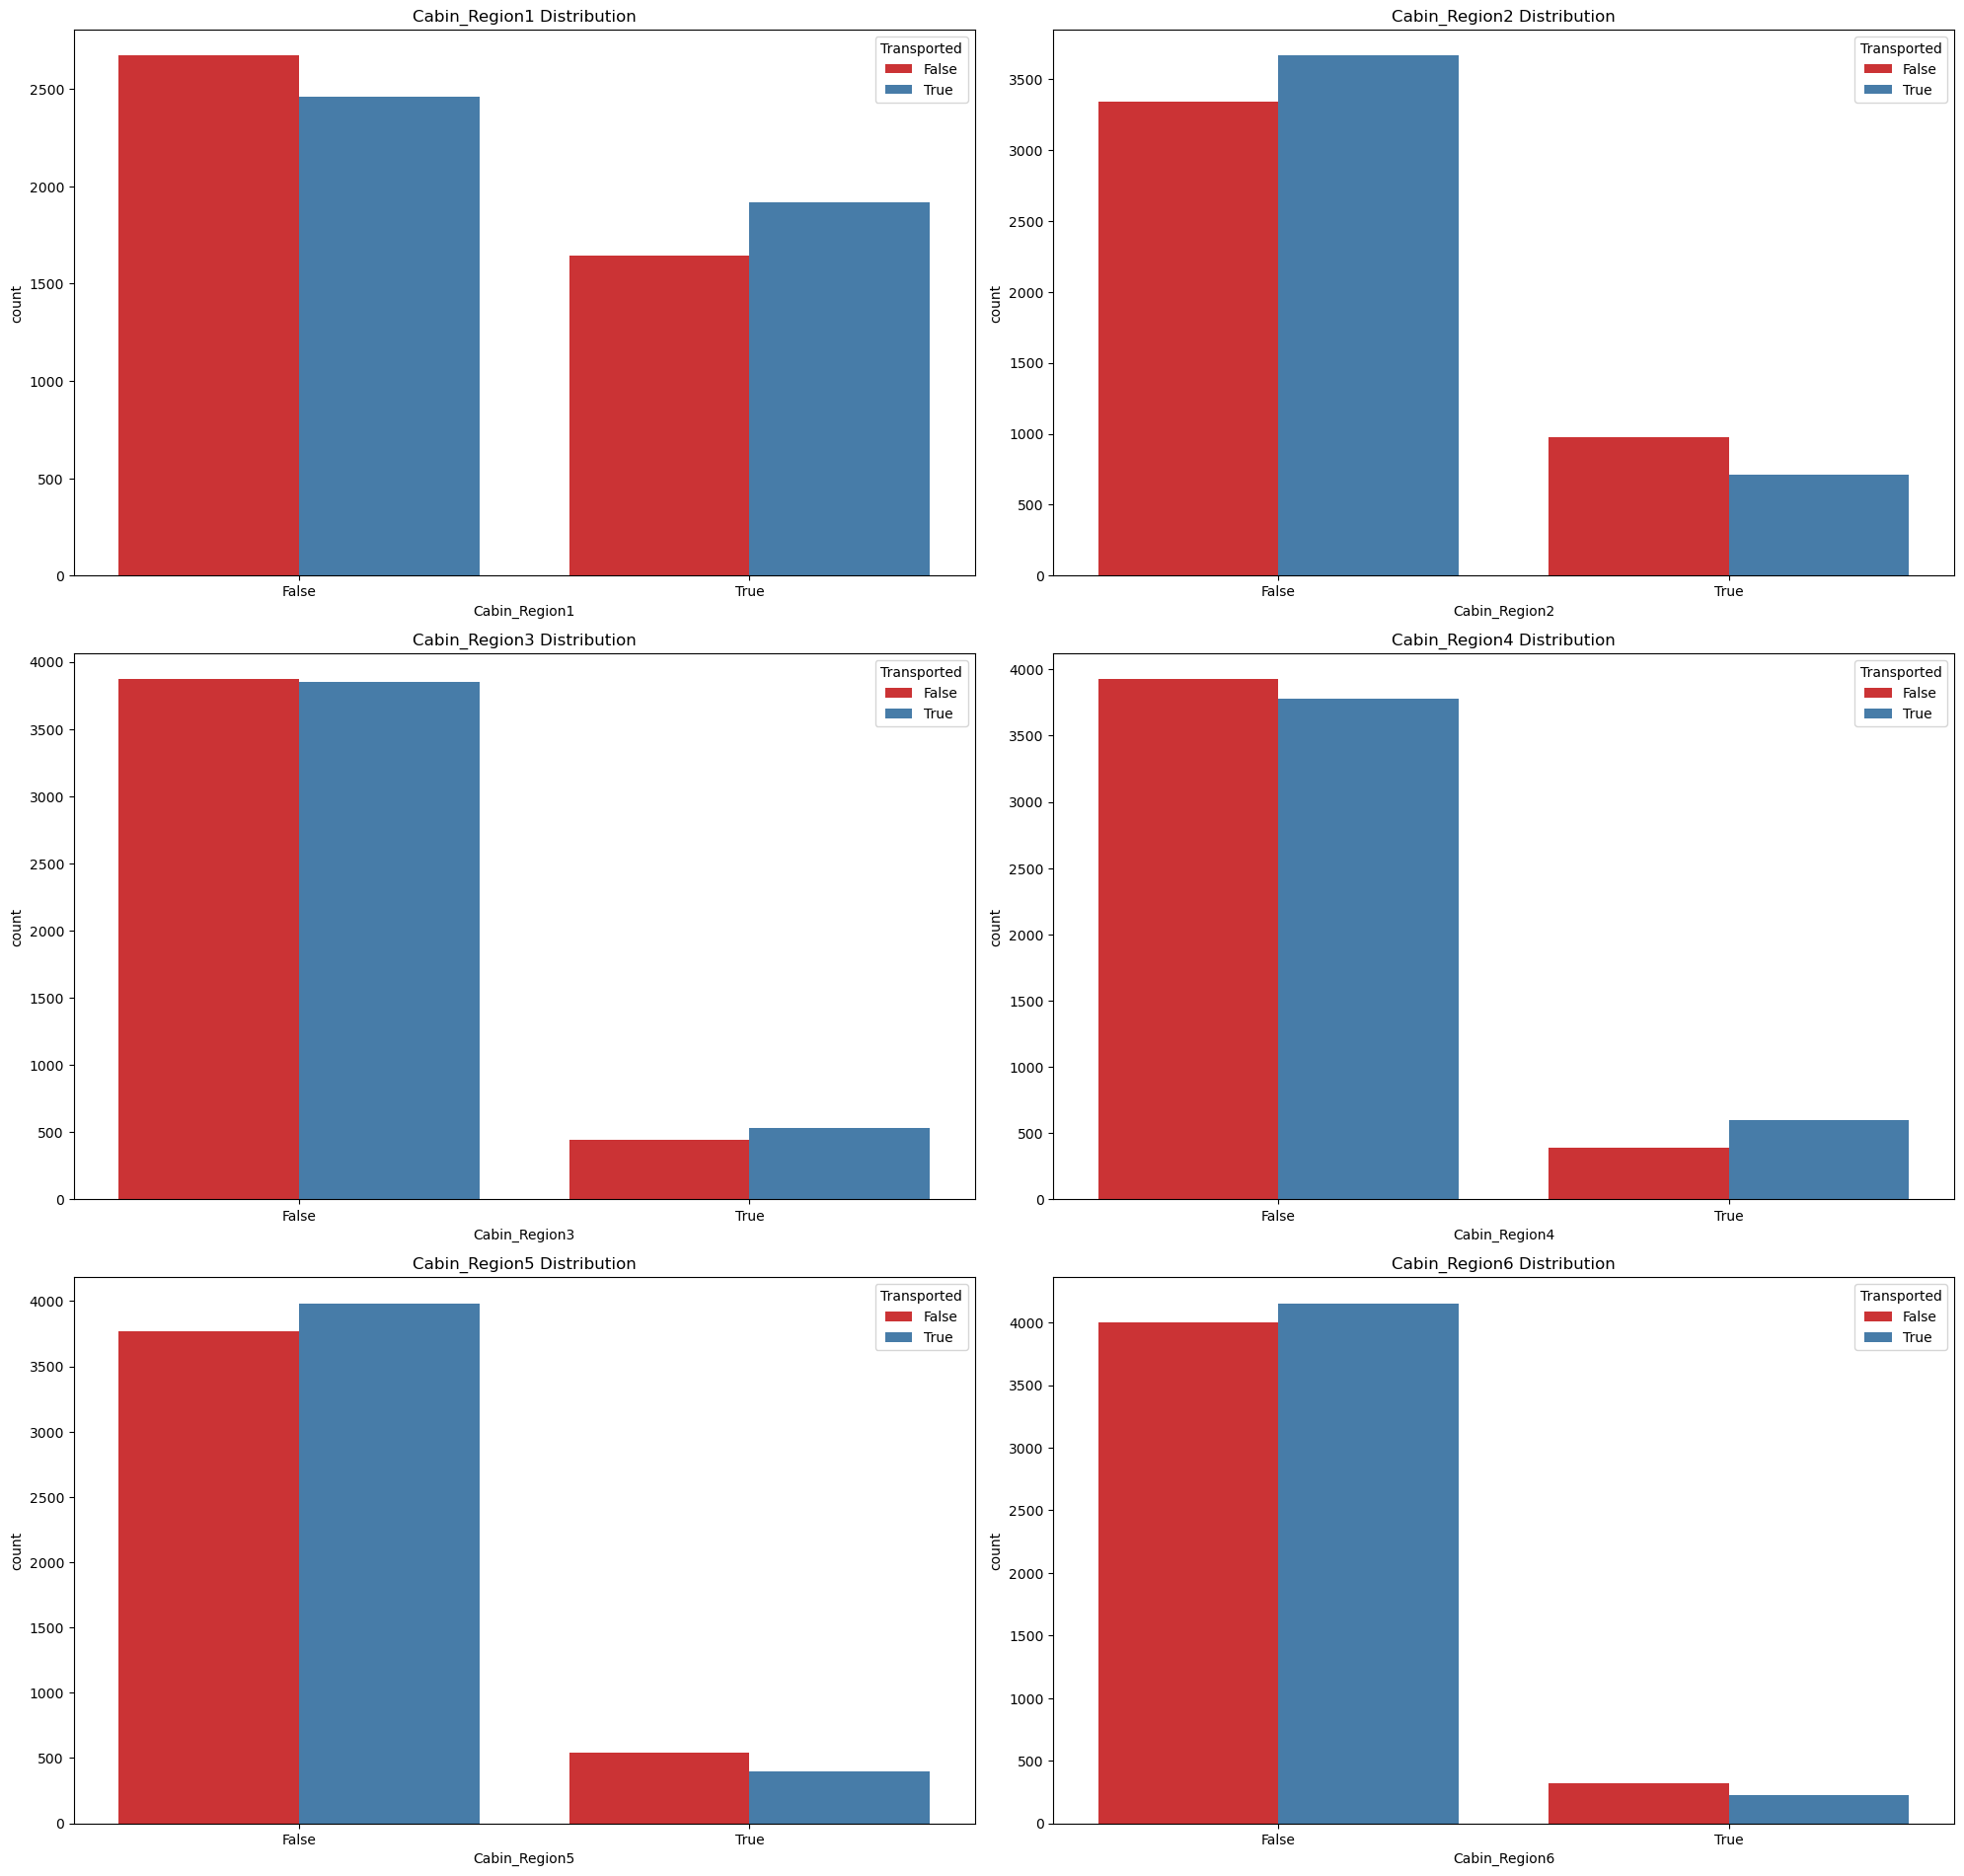

In [21]:

cols = ["Cabin_Region1","Cabin_Region2","Cabin_Region3","Cabin_Region4","Cabin_Region5","Cabin_Region6"]

plt.figure(figsize=(20,25))
for idx, value in enumerate(cols):
    plt.subplot(4,2,idx+1)
    sns.countplot(x=value, hue="Transported", data=train_df, palette="Set1")
    plt.title(f"{value} Distribution")
    plt.tight_layout()


Cabin_Region1 are Highly Transported when compared with other cabin regions.

Cabin region number is increasing passengers transport is decreasing

## Feature de l'Age

Text(0.5, 1.0, 'Age Group Distribution')

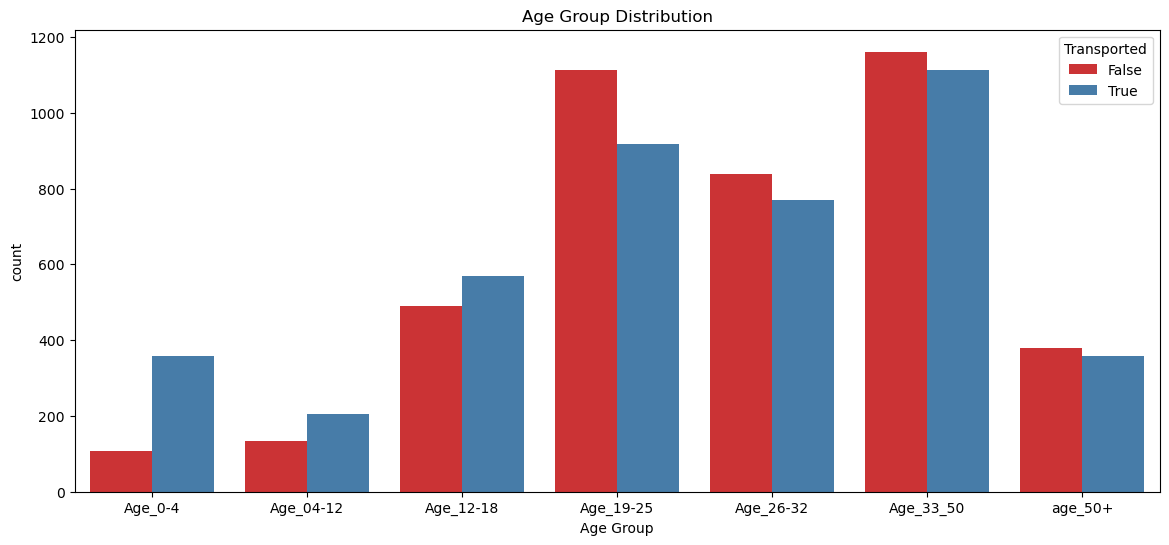

In [22]:
def age_group(df):
    age_group  = []
    for i in df["Age"]:
        if i<=4:
            age_group.append("Age_0-4")
        elif (i>4 and i<=12):
            age_group.append("Age_04-12")   
        elif (i>12 and i<=18):
            age_group.append("Age_12-18")
        elif (i>18 and i<=25):
            age_group.append("Age_19-25")
        elif (i>25 and i<=32):
            age_group.append("Age_26-32")
        elif (i>32 and i<=50):
            age_group.append("Age_33_50")
        elif (i>50):
            age_group.append("age_50+")
        else:
            age_group.append(np.nan)
        
    df["Age Group"] = age_group
age_group(train_df)
age_group(test_df)

order = sorted(train_df["Age Group"].value_counts().keys().to_list())

plt.figure(figsize=(14,6))
sns.countplot(x="Age Group",hue="Transported", data=train_df, palette="Set1",order=order)
plt.title("Age Group Distribution")


This new feature looks more relevent to our target data.

Age_0-12 & Age_0-18 are more likely to be transported compared to not transported.

Age_19-25 , Age_26_32 & Age_33_50 are less likely to be transported compared to not transported.

Age_50+ are almost equally transported compared to not transported.

## New Features with expenditude

In [23]:
exp_cols = ["RoomService","FoodCourt","ShoppingMall","Spa","VRDeck"]
train_df[exp_cols]

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,0.0,0.0,0.0,0.0,0.0
1,109.0,9.0,25.0,549.0,44.0
2,43.0,3576.0,0.0,6715.0,49.0
3,0.0,1283.0,371.0,3329.0,193.0
4,303.0,70.0,151.0,565.0,2.0
...,...,...,...,...,...
8688,0.0,6819.0,0.0,1643.0,74.0
8689,0.0,0.0,0.0,0.0,0.0
8690,0.0,0.0,1872.0,1.0,0.0
8691,0.0,1049.0,0.0,353.0,3235.0


La moyenne =  1441
La médiane =  716.0


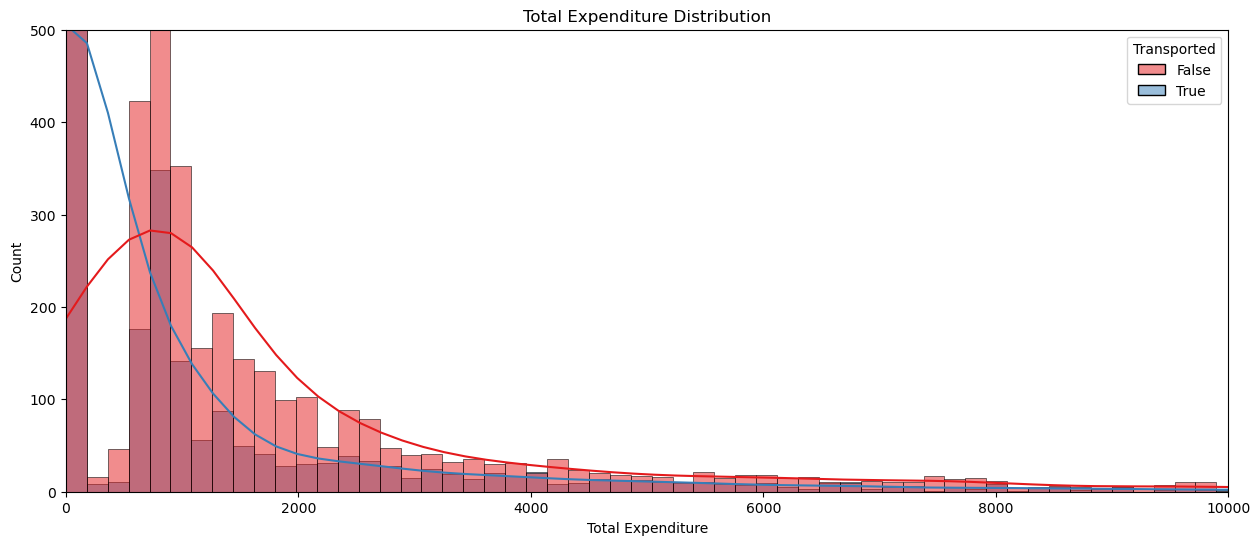

In [24]:
def new_exp_features(df):
    df["Total Expenditure"] = df[exp_cols].sum(axis=1)
    df["No Spending"] = (df["Total Expenditure"]==0)
new_exp_features(train_df)
new_exp_features(test_df)

plt.figure(figsize=(15,6))
sns.histplot(x="Total Expenditure", hue="Transported", data=train_df, kde=True, palette="Set1",bins=200)
plt.ylim(0,500)
plt.xlim(0,10000)
plt.title("Total Expenditure Distribution")

mean = round(train_df["Total Expenditure"].mean())
median = train_df["Total Expenditure"].median()


print("La moyenne = ",mean)
print("La médiane = ",median)

In [25]:
def expenditure_category(df):
    expense_category = []   
    for i in df["Total Expenditure"]:
        if i==0:
            expense_category.append("No Expense")
        elif (i>0 and i<=716):
            expense_category.append("Low Expense")
        elif (i>716 and i<=1441):
            expense_category.append("Medium Expense")
        elif (i>1441):
            expense_category.append("High Expense")

    
    df["Expenditure Category"] = expense_category

expenditure_category(train_df)
expenditure_category(test_df)


C:\Users\mkoud\AppData\Local\Temp\ipykernel_23516\2392633092.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


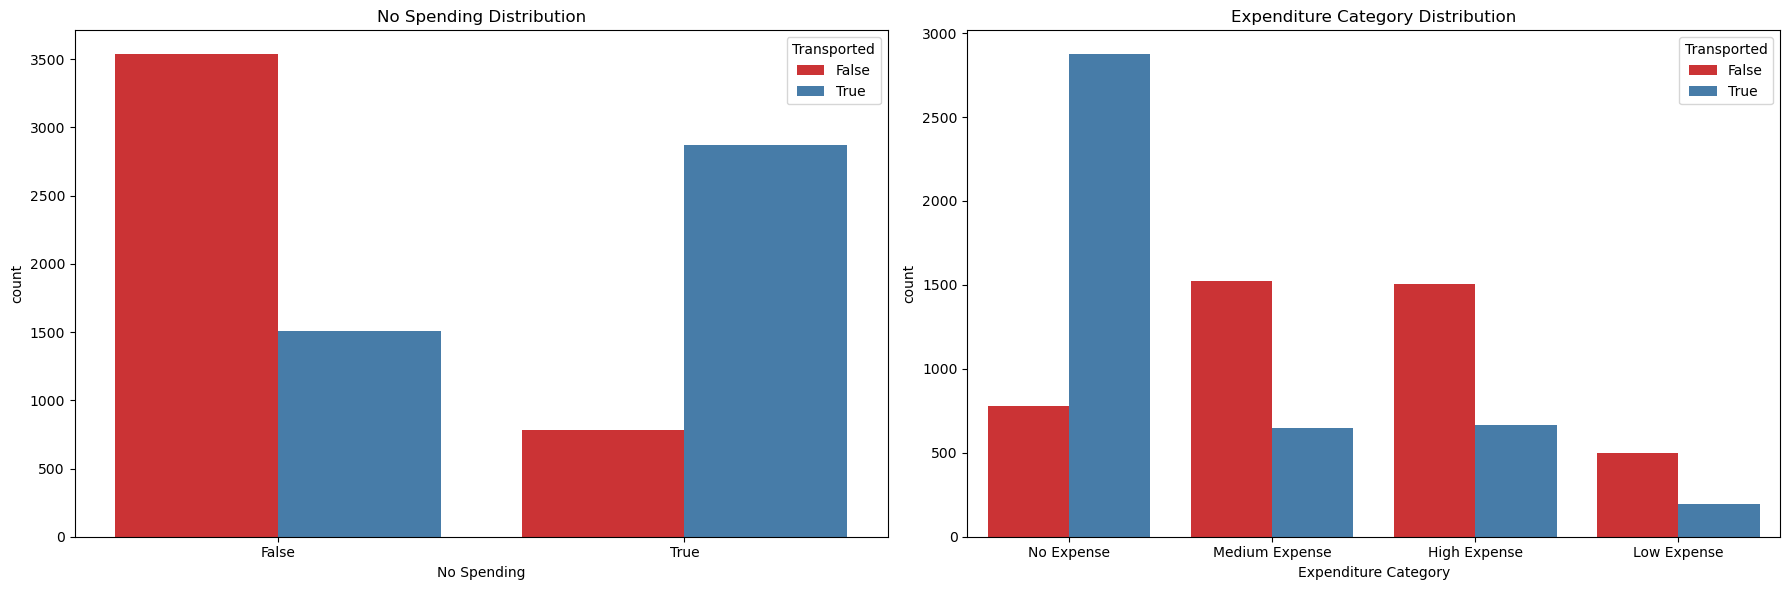

In [26]:

cols = ["No Spending", "Expenditure Category"]

plt.figure(figsize=(18,6))
for idx,column in enumerate(cols):
    plt.subplot(1,2,idx+1)
    sns.countplot(x=column, hue="Transported", data=train_df, palette="Set1")
    plt.title(f"{column} Distribution")
    plt.tight_layout()

In Total Expenditure feature we can observe that passengers having low total expenses are likely to be transported more.

In No Spending feature we can observe that passenger having No Spending are highly transported.

Expenditure Category feature we can confirm than passenger having No Expense are highly transported 

# Data pre-processing

In [27]:
z = train_df.isnull().sum()[train_df.isnull().sum()>0].to_frame().rename(columns={0:"No. of Missing values"})
z["% of Missing values"] = round(train_df.isnull().sum()[train_df.isnull().sum()>0]*100/len(train_df),2)
z

,No. of Missing values,% of Missing values
HomePlanet,201,2.31
CryoSleep,217,2.50
Destination,182,2.09
Age,179,2.06
VIP,203,2.34
RoomService,181,2.08
FoodCourt,183,2.11
ShoppingMall,208,2.39
Spa,183,2.11
VRDeck,188,2.16


handling missing values

In [28]:
cat_cols = train_df.select_dtypes(include=["object","bool"]).columns.tolist()
cat_cols.remove("Transported")
num_cols = train_df.select_dtypes(include=["int","float"]).columns.tolist()

In [29]:
print("Categorical Columns: ",cat_cols)
print("\n","-"*120)
print("\nNumerical Columns: ",num_cols)

Categorical Columns:  ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name', 'Travelling_Solo', 'Cabin_Deck', 'Cabin_Side', 'Cabin_Region1', 'Cabin_Region2', 'Cabin_Region3', 'Cabin_Region4', 'Cabin_Region5', 'Cabin_Region6', 'Age Group', 'No Spending', 'Expenditure Category']

 ------------------------------------------------------------------------------------------------------------------------

Numerical Columns:  ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Group_size', 'Total Expenditure']


In [30]:
# fill categorical feature
imputer1 = SimpleImputer(strategy="most_frequent")
# fill numerical feature
imputer2 = SimpleImputer(strategy="median")

def fill_missingno(df):
    df[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(df[cat_cols])
    df[num_cols] = SimpleImputer(strategy="median").fit_transform(df[num_cols])

fill_missingno(train_df)
fill_missingno(test_df)

print("Missing numbers left in train_df is: ", train_df.isnull().sum().sum())
print("Missing numbers left in test_df is: ", test_df.isnull().sum())

Missing numbers left in train_df is:  0
Missing numbers left in test_df is:  PassengerId             0
HomePlanet              0
CryoSleep               0
Cabin                   0
Destination             0
Age                     0
VIP                     0
RoomService             0
FoodCourt               0
ShoppingMall            0
Spa                     0
VRDeck                  0
Name                    0
Travelling_Solo         0
Group_size              0
Cabin_Deck              0
Cabin_Side              0
Cabin_Region1           0
Cabin_Region2           0
Cabin_Region3           0
Cabin_Region4           0
Cabin_Region5           0
Cabin_Region6           0
Age Group               0
Total Expenditure       0
No Spending             0
Expenditure Category    0
dtype: int64


In [31]:
print("Duplicate values in training data is: ",train_df.duplicated().sum())
print("Duplicate values in testing data is: ",test_df.duplicated().sum())

Duplicate values in training data is:  0
Duplicate values in testing data is:  0


In [32]:
print("Cardinality of features in numerical data is: ")
print(train_df.select_dtypes(include=["object"]).nunique())
print("\n","-"*50)
print("\nCardinality of features in categorical data is: ")
print(test_df.select_dtypes(include=["object"]).nunique())

Cardinality of features in numerical data is: 
PassengerId             8693
HomePlanet                 3
CryoSleep                  2
Cabin                   6561
Destination                3
VIP                        2
Name                    8473
Travelling_Solo            2
Cabin_Deck                 8
Cabin_Side                 2
Cabin_Region1              2
Cabin_Region2              2
Cabin_Region3              2
Cabin_Region4              2
Cabin_Region5              2
Cabin_Region6              2
Age Group                  7
No Spending                2
Expenditure Category       4
dtype: int64

 --------------------------------------------------

Cardinality of features in categorical data is: 
PassengerId             4277
HomePlanet                 3
CryoSleep                  2
Cabin                   3266
Destination                3
VIP                        2
Name                    4176
Travelling_Solo            2
Cabin_Deck                 8
Cabin_Side               

 We have done all feature engineering now we can drop features which have high cardinality.

In [33]:
##Extracting passengerId from test data because we need this for submitting our predictions on kaggle.
pass_df = test_df[["PassengerId"]]

In [34]:
cols = ["PassengerId","Cabin","Name"]
train_df.drop(columns =cols, inplace=True)
test_df.drop(columns=cols, inplace=True)

## applying log transformation on expenditure feature

C:\Users\mkoud\AppData\Local\Temp\ipykernel_23516\1249377592.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\mkoud\AppData\Local\Temp\ipykernel_23516\1249377592.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\mkoud\AppData\Local\Temp\ipykernel_23516\1249377592.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\mkoud\AppData\Local\Temp\ipykernel_23516\1249377592.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\mkoud\AppData\Local\Temp\ipykernel_23516\1249377592.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


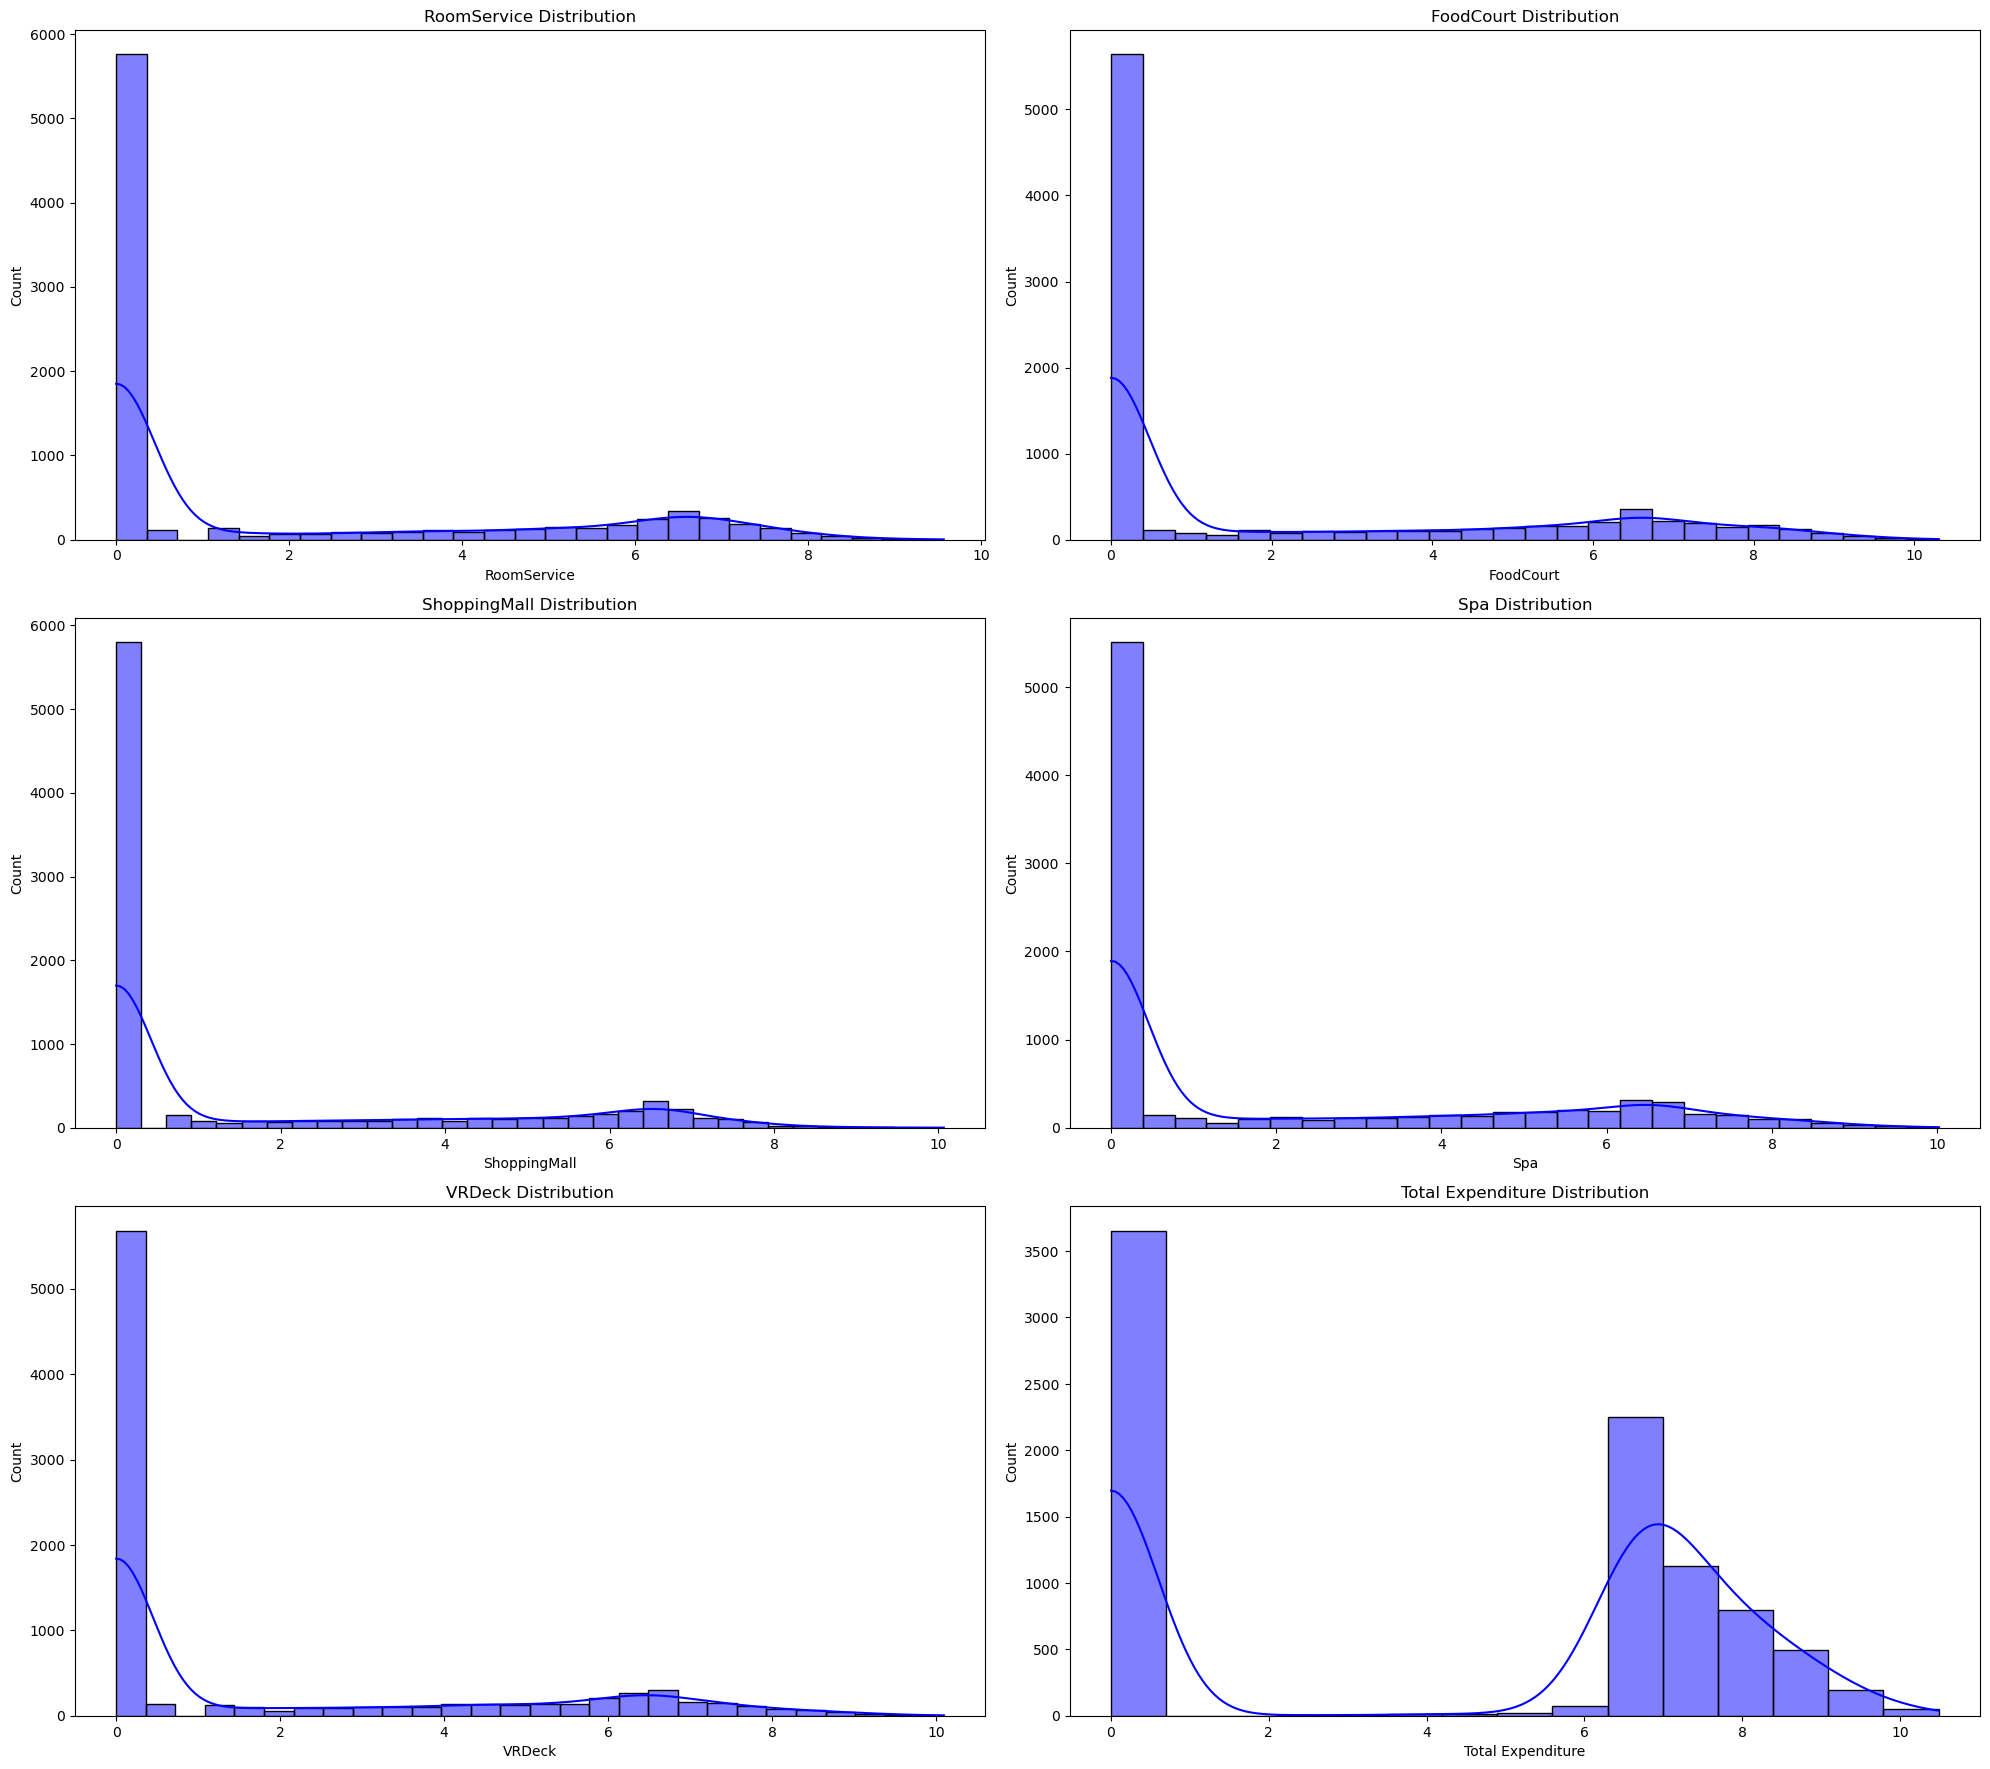

In [35]:
cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','Total Expenditure']

for value in cols: 
    train_df[value] = np.log(1+train_df[value])
    test_df[value] = np.log(1+test_df[value])
x=1
plt.figure(figsize=(20,35))
for i in cols:
    plt.subplot(6,2,x)
    sns.histplot(train_df[i],color="blue",kde="True")
    plt.title(f"{i} Distribution")
    plt.tight_layout()

    x+=1



## check data type

In [36]:
cols = ["CryoSleep","VIP","Travelling_Solo","No Spending","Cabin_Region1","Cabin_Region2","Cabin_Region3","Cabin_Region4",
       "Cabin_Region5","Cabin_Region6"]

train_df[cols] = train_df[cols].astype(bool)
test_df[cols] = test_df[cols].astype(bool)
train_df

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,...,Cabin_Region1,Cabin_Region2,Cabin_Region3,Cabin_Region4,Cabin_Region5,Cabin_Region6,Age Group,Total Expenditure,No Spending,Expenditure Category
0,Europa,False,TRAPPIST-1e,39.0,False,0.000000,0.000000,0.000000,0.000000,0.000000,...,True,False,False,False,False,False,Age_33_50,0.000000,True,No Expense
1,Earth,False,TRAPPIST-1e,24.0,False,4.700480,2.302585,3.258097,6.309918,3.806662,...,True,False,False,False,False,False,Age_19-25,6.602588,False,Medium Expense
2,Europa,False,TRAPPIST-1e,58.0,True,3.784190,8.182280,0.000000,8.812248,3.912023,...,True,False,False,False,False,False,age_50+,9.248021,False,High Expense
3,Europa,False,TRAPPIST-1e,33.0,False,0.000000,7.157735,5.918894,8.110728,5.267858,...,True,False,False,False,False,False,Age_33_50,8.551981,False,High Expense
4,Earth,False,TRAPPIST-1e,16.0,False,5.717028,4.262680,5.023881,6.338594,1.098612,...,True,False,False,False,False,False,Age_12-18,6.995766,False,Medium Expense
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,Europa,False,55 Cancri e,41.0,True,0.000000,8.827615,0.000000,7.404888,4.317488,...,True,False,False,False,False,False,Age_33_50,9.052165,False,High Expense
8689,Earth,True,PSO J318.5-22,18.0,False,0.000000,0.000000,0.000000,0.000000,0.000000,...,False,False,False,False,True,False,Age_12-18,0.000000,True,No Expense
8690,Earth,False,TRAPPIST-1e,26.0,False,0.000000,0.000000,7.535297,0.693147,0.000000,...,False,False,False,False,False,True,Age_26-32,7.535830,False,High Expense
8691,Europa,False,55 Cancri e,32.0,False,0.000000,6.956545,0.000000,5.869297,8.082093,...,False,False,True,False,False,False,Age_26-32,8.442039,False,High Expense


feature encoding

nominal categorical features : One hot encoding

ordinal categorical features : LabelEncoding

In [37]:
nominal_cat_cols_one_Hot = ["HomePlanet","Destination"]
ordinal_cat_cols_Label = ["CryoSleep","VIP","Travelling_Solo","Cabin_Deck","Cabin_Side","Cabin_Region1","Cabin_Region2",
                    "Cabin_Region3","Cabin_Region4","Cabin_Region5","Cabin_Region6","Age Group","No Spending",
                    "Expenditure Category"]


train_df[ordinal_cat_cols_Label] = train_df[ordinal_cat_cols_Label].apply(LabelEncoder().fit_transform)

test_df[ordinal_cat_cols_Label] = test_df[ordinal_cat_cols_Label].apply(LabelEncoder().fit_transform)

train_df = pd.get_dummies(train_df, columns= nominal_cat_cols_one_Hot)

test_df = pd.get_dummies(test_df, columns = nominal_cat_cols_one_Hot)

In [38]:
print(train_df)

      CryoSleep   Age  VIP  RoomService  FoodCourt  ShoppingMall       Spa  \
0             0  39.0    0     0.000000   0.000000      0.000000  0.000000   
1             0  24.0    0     4.700480   2.302585      3.258097  6.309918   
2             0  58.0    1     3.784190   8.182280      0.000000  8.812248   
3             0  33.0    0     0.000000   7.157735      5.918894  8.110728   
4             0  16.0    0     5.717028   4.262680      5.023881  6.338594   
...         ...   ...  ...          ...        ...           ...       ...   
8688          0  41.0    1     0.000000   8.827615      0.000000  7.404888   
8689          1  18.0    0     0.000000   0.000000      0.000000  0.000000   
8690          0  26.0    0     0.000000   0.000000      7.535297  0.693147   
8691          0  32.0    0     0.000000   6.956545      0.000000  5.869297   
8692          0  44.0    0     4.844187   8.452975      0.000000  0.000000   

        VRDeck  Transported  Travelling_Solo  ...  Age Group  \

In [39]:
train_df["Transported"].replace({False:0,True:1},inplace=True)
train_df = train_df.drop(columns=["Age"])
test_df = test_df.drop(columns=["Age"])
train_df


,CryoSleep,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Travelling_Solo,Group_size,...,Age Group,Total Expenditure,No Spending,Expenditure Category,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,1,1.0,...,5,0.000000,1,3,False,True,False,False,False,True
1,0,0,4.700480,2.302585,3.258097,6.309918,3.806662,1,1,1.0,...,3,6.602588,0,2,True,False,False,False,False,True
2,0,1,3.784190,8.182280,0.000000,8.812248,3.912023,0,0,2.0,...,6,9.248021,0,0,False,True,False,False,False,True
3,0,0,0.000000,7.157735,5.918894,8.110728,5.267858,0,0,2.0,...,5,8.551981,0,0,False,True,False,False,False,True
4,0,0,5.717028,4.262680,5.023881,6.338594,1.098612,1,1,1.0,...,2,6.995766,0,2,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0,1,0.000000,8.827615,0.000000,7.404888,4.317488,0,1,1.0,...,5,9.052165,0,0,False,True,False,True,False,False
8689,1,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,1,1.0,...,2,0.000000,1,3,True,False,False,False,True,False
8690,0,0,0.000000,0.000000,7.535297,0.693147,0.000000,1,1,1.0,...,4,7.535830,0,0,True,False,False,False,False,True
8691,0,0,0.000000,6.956545,0.000000,5.869297,8.082093,0,0,2.0,...,4,8.442039,0,0,False,True,False,True,False,False


In [40]:
test_df.head()

,CryoSleep,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Travelling_Solo,Group_size,Cabin_Deck,...,Age Group,Total Expenditure,No Spending,Expenditure Category,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,1,0,0.000000,0.000000,0.000000,0.000000,0.00000,1,1.0,6,...,4,0.000000,1,3,True,False,False,False,False,True
1,0,0,0.000000,2.302585,0.000000,7.945910,0.00000,1,1.0,5,...,3,7.949091,0,0,True,False,False,False,False,True
2,1,0,0.000000,0.000000,0.000000,0.000000,0.00000,1,1.0,2,...,4,0.000000,1,3,False,True,False,True,False,False
3,0,0,0.000000,8.802823,0.000000,5.204007,6.37332,1,1.0,2,...,5,8.911800,0,0,False,True,False,False,False,True
4,0,0,2.397895,0.000000,6.455199,0.000000,0.00000,1,1.0,5,...,3,6.470800,0,1,True,False,False,False,False,True


## Selecting features & label for model training

In [41]:
x = train_df.drop(columns=["Transported"])
y = train_df[["Transported"]]
xtrain, xval , ytrain, yval =  train_test_split(x,y, test_size=0.2, random_state=1)

logic = LogisticRegression().fit(x,y)
logic.coef_
logic.score(x,y)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7774071091682964

In [42]:
from sklearn import svm
from sklearn.model_selection import cross_val_score
clf = svm.SVC().fit(x,y)
scores = cross_val_score(clf, x, y, cv=10)
scores

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

array([0.80804598, 0.77931034, 0.77816092, 0.79401611, 0.76409666,
       0.80207135, 0.81472957, 0.80897583, 0.81242808, 0.78711162])